# Car Price Prediction

> I don't know the exact source of this dataset.  
> Somewhere on [Kaggle](https://www.kaggle.com/) I think...

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## 1. Importing the data

In [17]:
# load data
file_path = pathlib.Path.cwd().parent / '.data/car_price_prediction.csv'
data = pd.read_csv(filepath_or_buffer=file_path)

In [18]:
# let's get a preview
data

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657
...,...,...,...,...,...,...,...,...
995,Toyota,Model D,2002,1.9,5445,Petrol,Manual,22765.597091
996,Honda,Model B,2020,3.1,149112,Diesel,Manual,30392.575567
997,Ford,Model C,2008,1.9,195387,Petrol,Automatic,16446.892292
998,Toyota,Model A,2003,4.4,246,Petrol,Automatic,27396.156708


---
## 2. Observing & cleaning

In [19]:
# are there missing values?
data.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

In [20]:
# are there duplicate?
data.duplicated().sum()

np.int64(0)

*Owkay...* Lets preceed!

---
## 3. Mathematical Prespective

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   str    
 1   Model         1000 non-null   str    
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   str    
 6   Transmission  1000 non-null   str    
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), str(4)
memory usage: 62.6 KB


In [22]:
data.describe()

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


## Visualizing the data

- First we divide the columns in features(`X`) and label(`y`).
- Then visualize the selected features to see their relation with label.

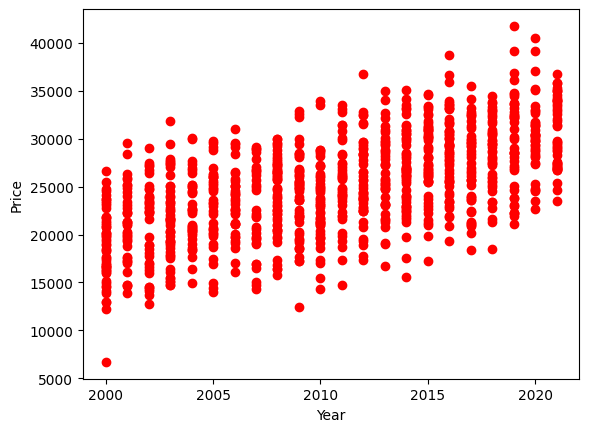

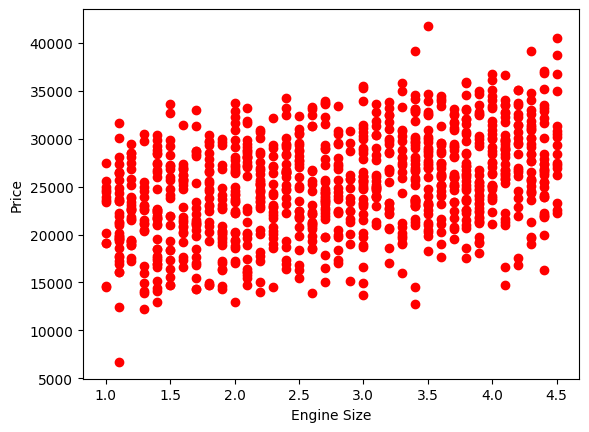

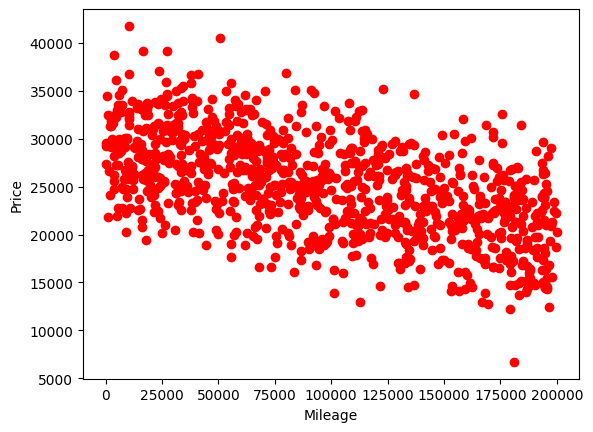

In [23]:
X = data[['Year', 'Engine Size', 'Mileage']]
y = data['Price']

for col in X.columns:
    plt.scatter(X[col], y, color='r')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.show()

## Splitting & Training

0.8500184075928485


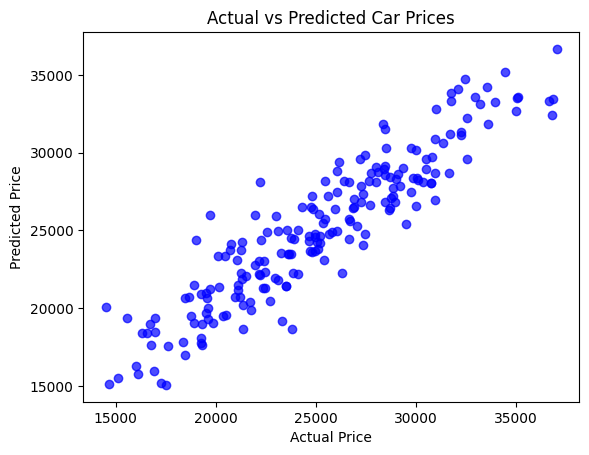

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(model.score(X_test, y_test))
plt.scatter(y_test, y_pred, color='b', alpha=0.7)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()

In [25]:
print(model.predict([[2025, 5, 1000]]))

[41530.048201]


/home/ankit/vsc/Data Science/Machine Learning/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
